<a href="https://colab.research.google.com/github/DavidSenseman/STA1403/blob/main/Chapter_03A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<!-- STA1403_CHAPTER_03A:Rev 1 -->

---------------------------
**COPYRIGHT NOTICE:** This Jupyterlab Notebook is a Derivative work of [Jeff Heaton](https://github.com/jeffheaton) licensed under the Apache License, Version 2.0 (the "License"); You may not use this file except in compliance with the License. You may obtain a copy of the License at

> [http://www.apache.org/licenses/LICENSE-2.0](http://www.apache.org/licenses/LICENSE-2.0)

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.

------------------------

# **STA 1403: Biostatistics**

## **Chapter 3: Exploring Relationships**

Instructor: [David Senseman](mailto:David.Senseman@utsa.edu), [Department of Biology, Health and the Environment](https://sciences.utsa.edu/bhe/), [UT San Antonio](https://www.utsa.edu/)

#### Contents
* **3.1 : Visualizing and Summarizing Relationships Between Variables**
* **3.2 : Relationships Between Two Numerical Random Variables**
* 3.3 : Relationships Between Categorical Variables
* 3.4 : Relationships Between Numerical and Categorical Variables
* 3.5 : Advanced



## Google Colab Instructions

Run next code cell to map this Colab lesson's folder /content/drive to your Google Drive. This will allow you keep a copy of this Colab notebook which **_is_** your course textbook.

In [ ]:
# @title **Run this cell first**
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    Colab = True
    print("Note: Using Google CoLab")
    !curl ipinfo.io
except:
    print("**WARNING**: Your GDrive is not mapped to /content/drive ")
    print("**WARNING**: Your work will not be saved!")
    Colab = False

Mounted at /content/drive
Note: Using Google CoLab
{
  "ip": "34.21.181.153",
  "hostname": "153.181.21.34.bc.googleusercontent.com",
  "city": "Singapore",
  "region": "Singapore",
  "country": "SG",
  "loc": "1.2897,103.8501",
  "org": "AS396982 Google LLC",
  "postal": "018989",
  "timezone": "Asia/Singapore",
  "readme": "https://ipinfo.io/missingauth"
}

You should see something _similar_ to the following output:
```text
Mounted at /content/drive
Note: Using Google CoLab
{
  "ip": "34.139.115.187",
  "hostname": "187.115.139.34.bc.googleusercontent.com",
  "city": "North Charleston",
  "region": "South Carolina",
  "country": "US",
  "loc": "32.8546,-79.9748",
  "org": "AS396982 Google LLC",
  "postal": "29415",
  "timezone": "America/New_York",
  "readme": "https://ipinfo.io/missingauth"
}
```

## Test Your STA1403 Key

Run the next cell to test whether your STA1403 Key is correctly installed in your Colab Secrets. If asked, grant access to your Colab Secrets.

In [ ]:
# @title Test Your STA1403 KEY

from google.colab import userdata
import os

# Check if STA1403 key is properly loaded
try:
    # 1. Get the key from Secrets
    STA1403_KEY = userdata.get('STA1403_KEY')

    # 2. Set it as an environment variable
    os.environ['STA1403_KEY'] = STA1403_KEY

    print("STA1403 key loaded and environment variable set successfully!")
    print(f"Key length: {len(STA1403_KEY)}")

except Exception as e:
    print(f"Error loading STA1403 key: {e}")
    print("Please set your STA1403 key in Google Colab:")
    print("1. Go to Secrets in the left sidebar (key icon)")
    print("2. Create a new secret named 'STA1403_KEY'")
    print("3. Paste your STA1403 key and toggle 'Notebook access' on")

STA1403 key loaded and environment variable set successfully!
Key length: 26


If your STA1403 Key is correctly stored in your Colab Secrets, you should see the following output:
```text
STA1403 key loaded and environment variable set successfully!
Key length: 28
```

If your STA1403 Key is not correct, you need to contact your course instructor. You will **not** be able to submit this Colab notebook for a grade until you resolve this issue.

# **Chapter 3 : Exploring Relationships**

## **3.1 Visualizing and Summarizing Relationships Between Variables**

In the previous chapter, we focused on using graphs and summary statistics to explore the distribution of individual variables. This chapter is dedicated to using graphs and summary statistics to investigate relationships between two or more variables. Our objective is to develop a high-level understanding of the type and strength of relationships between variables. Note that at this point, we are not making formal conclusions regarding the existence of relationship or whether the relationship, if exists, is strong or not. We do that formally later in this book. Here, we explore the observed data to detect possible relationships and use summary statistics to measure the strength of relationships.

As before, the appropriate tools for exploring data depend on the types of variables. Therefore, this chapter is organized as follows. We start by discussing some techniques for exploring relationships between two numerical variables. Next, we look at some statistics that are commonly used to capture the relationship between two categorical variables. Mainly, we focus on cases where both categorical variables are binary (i.e., variables can take only two possible values). More general situations are discussed later in the book. Finally, we discuss some common techniques for exploring relationships between a categorical variable and a numerical variable.

## **3.2 Relationships Between Two Numerical Random Variables**

We start our discussion of relationships between numerical variables by looking at a data set based on a study conducted by Dr. Fisher from Human Performance Research Center at Brigham Young University. This observational study involved measuring percent body fat as the target variable, along with several explanatory variables such as age, weight, height, and abdomen circumference for a sample of 252 men. Example 1 shows the Python code to read this datafile from the course fileserver and store the information in a Pandas DataFrame called `bodywt_df`.


## Example 1: Read a Datafile and View Its Contents

The code in the cell below uses `pd.read_csv()` to read a data file from the course file server `https://biologicslab.co`. In this example, the name of the file is `bodyfat`.

In addition to the data file name, one additional argument is passed, the data separator character, in this file, the data separator is a comma (`sep=','`).  

The command starts with `bodyfat_df =` to tell Python to store what it reads in a **DataFrame** called `bodyfat_df`.

We had also add an additional argument to the command that reads the datafile:`na_values=["?", "NA", "null", ""]`. This additional argument is necessary to keep any missing values.

To see what is stored in our `bodyfat_df` we use `bodyfat_df.head()` to print out the first 5 records.

In [ ]:
# @title Example 1: Create Dataframe from File Download

import pandas as pd

# Define variables
file_server="https://biologicslab.co"
file_dir="/STA1403/data/"
file_name="bodyfat"

# Build datafile name
datafile=file_server + file_dir + file_name

# Store datafile in dataframe
bodyfat_df = pd.read_csv(datafile, sep=',', na_values=["?", "NA", "null", ""])

# Print out first 5 records in dataframe
bodyfat_df.head()


,density,percent_body_fat,age,weight_lbs,height_in,neck_cm,chest_cm,abdomen_cm,hip_cm,thigh_cm,knee_cm,ankle_cm,biceps_cm,forearm_cm,wrist_cm
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


If the code is correct, you should see the following output:

![__](https://biologicslab.co/STA1403/images/chapter_03/chapter_03A_image05A.png)

## **Exercise 1A: Read a Datafile and View Its Contents**

In the cell below, write the code to read a file called `USmelanoma` and display the first 5 records using the `df.head()` method.

**Code Hints:**
1. Copy-and-paste Example 1 into the cell below.
2. Change the file name from `bodyfat` to `USmelanoma`
3. Change `bodyfat_df` to `USmel_df`


In [ ]:
# @title Exercise 1A: Create Dataframe from File Download

import pandas as pd

# Define variables
file_server="https://biologicslab.co"
file_dir="/STA1403/data/"
file_name="USmelanoma"

# Build datafile name
datafile=file_server + file_dir + file_name

# Store datafile in dataframe
USmel_df = pd.read_csv(datafile, sep=',', na_values=[" ", "NA", "null", ""])

# Print out selected records in dataframe
USmel_df.head()

,rownames,mortality,latitude,longitude,ocean
0,Alabama,219,33.0,87.0,yes
1,Arizona,160,34.5,112.0,no
2,Arkansas,170,35.0,92.5,no
3,California,182,37.5,119.5,yes
4,Colorado,149,39.0,105.5,no


If your code is correct, you should see the following output:

![__](https://biologicslab.co/STA1403/images/chapter_03/chapter_03A_image02A.png)

## **Exercise 1B: Read a Datafile and View Its Contents**

In the cell below, write the code to read a file called `birthwt` and create a DataFrame called `birthwt_df`. Display the first 5 records using the `df.head()` method.

**Code Hints:**
1. Copy-and-paste Example 1 into the cell below.
2. Change the file name from `bodyfat` to `birthwt`
3. Change `bodyfat_df` to `birthwt_df`


In [ ]:
# @title Exercise 1B: Create Dataframe from File Download

import pandas as pd

# Define variables
file_server="https://biologicslab.co"
file_dir="/STA1403/data/"
file_name="birthwt"

# Build datafile name
datafile=file_server + file_dir + file_name

# Store datafile in dataframe
birthwt_df = pd.read_csv(datafile, sep=',', na_values=[" ", "NA", "null", ""])

# Print out selected records in dataframe
birthwt_df.head()

,low,age,lwt,race,smoke,ptl,ht,ui,ftv,bwt
0,0,19,182.0,black,0,0,0,1,0,2523
1,0,33,155.0,other,0,0,0,0,3,2551
2,0,20,105.0,white,1,0,0,0,1,2557
3,0,21,108.0,white,1,0,0,1,2,2594
4,0,18,107.0,white,1,0,0,1,0,2600


If your code is correct, you should see the following output:

![__](https://biologicslab.co/STA1403/images/chapter_03/chapter_03A_image14A.png)

## **_Scatterplots_**

Using **scatterplots**, we could detect possible relationships between two numerical variables. If a relationship exists, we could also learn about its type. From the scatterplots shown below, we can see that changes in one variable coincides with substantial **systematic** changes (increase or decrease) in the other variable. Therefore, the two variables seem to be related. (We make a formal judgement regarding the existence of relationship later.) In these examples, the systemic changes are captured by the straight lines passing through the data points on the graphs. (Around the lines, there are also random changes in observed values without any clear patterns.)

When two variables are related, and the overall relationship can be presented by a straight line, we say that the two variables have **linear relationship**. More specifically, we say that percent body fat and abdomen circumference have _positive linear relationship_ since increase in one variable tends to coincide with increase in the other one. In contrast, we say that annual mortality rate due to malignant melanoma and latitude have a _negative linear relationship_ since increase in one variable tends to coincide with decrease in another one. Note that the directions (positive or negative) of these two linear relationships correspond to the slope of the straight lines presenting the overall patterns.

Suppose that we are interested in examining the relationship between percent body fat and abdomen circumference among men. We can visualize this relationship by creating a **scatterplot** as shown in Example 2.

## Example 2: Generate a Scatterplot

The code in the cell below, shows the Python code to generate a scatterplot of waist size(`abdomen_cm`) as the $x$ variable, and percentage of body fat (`percent_body_fat`) as the $y$ variable.

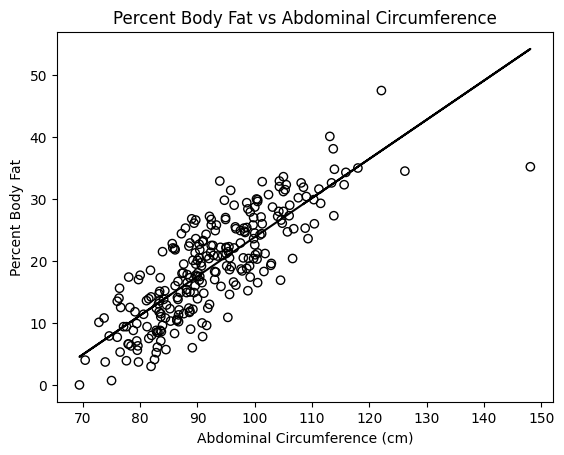

In [ ]:
# @title Example 2: Generate a Scatterplot

import matplotlib.pyplot as plt
import numpy as np

# Define variables
dataset = bodyfat_df            # DataFrame name
colName1 = "abdomen_cm"         # Column with x values
colName2 = "percent_body_fat"   # Column with y value
plotTitle = "Percent Body Fat vs Abdominal Circumference"
xLabel = "Abdominal Circumference (cm)"
yLabel = "Percent Body Fat"

# Assign x and y
x = dataset[colName1]
y = dataset[colName2]

# Create the scatter plot with open circles
plt.scatter(x, y, facecolors='none', edgecolors='black')

# Calculate the line of best fit
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

# Add the line to the plot
plt.plot(x, p(x), color='black')

# Generate the plot
plt.title(plotTitle)
plt.xlabel(xLabel)
plt.ylabel(yLabel)
plt.show()

If the code is correct, you should see the following output:

![__](https://biologicslab.co/STA1403/images/chapter_03/chapter_03A_image02B.png)

This is a scatterplot of percent body fat by abdomen circumference. There is a clear positive linear relationship between the two variables. The x-axis represents possible values of abdomen circumference, and the y-axis represents possible values of percent body fat. Each point on the graph represents one individual in the sample. The plot suggests that the increase in percent body fat tends to coincide with the increase in abdomen circumference. Therefore, the two variables seem to be related with each other. In this case, the relationship is simply an association and should not be regarded as causation since the data come from an observational study.


## **Exercise 2A: Generate a Scatterplot**

In the cell below, generate a scatterplot of `latitude` and `mortality` from the `USmel_df` DataFrame.

**Code Hints:**
1. Copy-and-paste Example 2 into the cell below.
2. Change the variables so they read as shown in this code block:
```Python
# Define variables
dataset = USmel_df            # DataFrame name
colName1 = "latitude"         # Column with x values
colName2 = "mortality"        # Column with y value
plotTitle = "Latitude vs Annual Mortality"
xLabel = "Latitude (degrees)"
yLabel = "Annual mortality rate"    
```

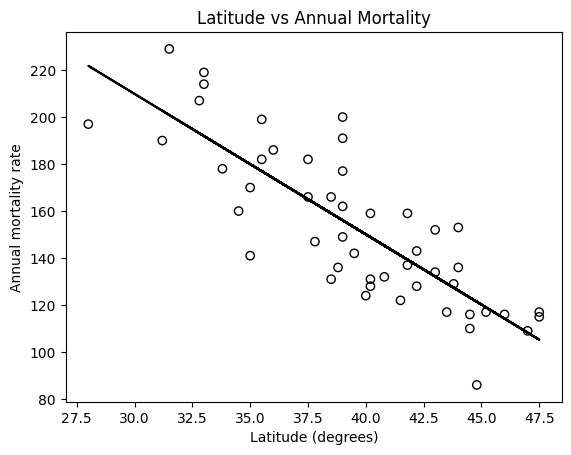

In [ ]:
# @title Exercise 2A: Generate a Scatterplot

import matplotlib.pyplot as plt
import numpy as np

# Define variables
dataset = USmel_df            # DataFrame name
colName1 = "latitude"         # Column with x values
colName2 = "mortality"        # Column with y value
plotTitle = "Latitude vs Annual Mortality"
xLabel = "Latitude (degrees)"
yLabel = "Annual mortality rate"

# Assign x and y
x = dataset[colName1]
y = dataset[colName2]

# Create the scatter plot with open circles
plt.scatter(x, y, facecolors='none', edgecolors='black')

# Calculate the line of best fit
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

# Add the line to the plot
plt.plot(x, p(x), color='black')

# Generate the plot
plt.title(plotTitle)
plt.xlabel(xLabel)
plt.ylabel(yLabel)
plt.show()

If the code is correct, you should see the following output:

![__](https://biologicslab.co/STA1403/images/chapter_03/chapter_03A_image04A.png)


The scatterplot of annual mortality rate (per 100,000,000 population) and latitude (in degrees) showing the relationship between the annual mortality rate due to malignant melanoma for US states and the latitude of their geographical centers. The data, which are discussed in Fisher and van Belle (1993), are collected from the population of white males in the US during 1950–1969. Each point represents a US state. The two variables are clearly associated since the increase in latitude tends to coincide with the decrease in mortality rate.


Using scatterplots, we could detect possible relationships between two numerical variables. If a relationship exists, we could also learn about its type. From the scatterplots shown above from Example 2 and **Exercise 2**, we can see that changes in one variable coincides with substantial systematic changes (increase or decrease) in the other variable. Therefore, the two variables seem to be related. (We make a formal judgement regarding the existence of relationship later.) In these examples, the systemic changes are captured by the straight lines passing through the data points on the graphs. (Around the lines, there are also random changes in observed values without any clear patterns.) When two variables are related, and the overall relationship can be presented by a straight line, we say that the two variables have **linear relationship**. More specifically, we say that percent body fat and abdomen circumference have positive linear relationship since increase in one variable tends to coincide with increase in the other one. In contrast, we say that annual mortality rate due to malignant melanoma and latitude have negative linear relationship since increase in one variable tends to coincide with decrease in another one. Note that the directions (positive or negative) of these two linear relationships correspond to the slope of the straight lines presenting the overall patterns.

## **Exercise 2B: Generate a Scatterplot**

In the cell below, generate a scatterplot of `height_in` and `percent_body_fat` from the `bodyfat_df` DataFrame.


**Code Hints:**
1. Copy-and-paste Example 2 into the cell below.
2. Change the variables so they read as shown in this code block:
```Python
# Define variables
dataset = bodyfat_df                 # DataFrame name
colName1 = "height_in"               # Column with x values
colName2 = "percent_body_fat"        # Column with y value
plotTitle = "Percent Body Fat vs Height (inch)"
xLabel = "Height (in)"
yLabel = "Percent Body Fat"  
```

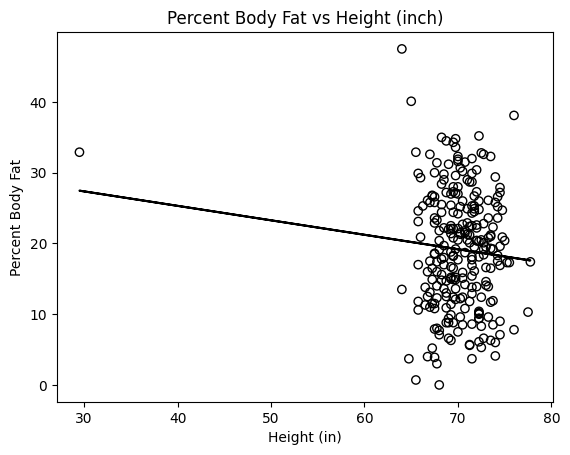

In [ ]:
# @title Exercise 2B: Generate a Scatterplot

import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

# Define variables
dataset = bodyfat_df             # DataFrame name
colName1 = "height_in"           # Column with x values
colName2 = "percent_body_fat"    # Column with y value
plotTitle = "Percent Body Fat vs Height (inch)"
xLabel = "Height (in)"
yLabel = "Percent Body Fat"

# Assign x and y
x = dataset[colName1]
y = dataset[colName2]

# Create the scatter plot with open circles
plt.scatter(x, y, facecolors='none', edgecolors='black')

# Calculate the line of best fit
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

# Add the line to the plot
plt.plot(x, p(x), color='black')

# Generate the plot
plt.title(plotTitle)
plt.xlabel(xLabel)
plt.ylabel(yLabel)
plt.show()


If the code is correct, you should see the following output:

![__](https://biologicslab.co/STA1403/images/chapter_03/chapter_03A_image03B.png)

Now let us examine the relationship between the height variable (height in inches) and percent_body fat shown in this scatterplot. The isolated leftmost point is an outlier: a person whose height is around 30 inches, and his percent body fat is relatively high. In this sample, everyone else's height is above 60 inches. This is possibly a data entry mistake. Looking at the straight line that represents the overall pattern, there seems to be a negative linear relationship between the two variables. However, the overall pattern (represented by the straight line) is heavily influenced by the outlier. Here, for the illustration purpose, we assume that this is in fact a data entry mistake. Further, we assume that we cannot find the correct values for this subject. Therefore, we remove the outlier from the sample.

## Remove Outlier from Data Set

If you look at this scatterplot, you should notice that there is one individual (data point) with an x value less than 30. In other words the data claims to include one person who is **only _2ft 6 inch_ tall!** This data point is clearly _outside_ the cluster of the other height values that range from 5ft 4in (64 inch) to 6ft 6in (78 in). We call this outside data point an **outlier**. We will discuss how to handle outliers later in the course. For the moment, the code in the cell below shows how we can remove this outlier from of data set.  

In [ ]:
# @title Remove Outlier from Data Set

# Define variables
dataset = bodyfat_df                 # DataFrame name
colName1 = "height_in"               # Column with x values


# Calculate IQR
Q1 = dataset[colName1].quantile(0.25)
Q3 = dataset[colName1].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Make a local copy
dsCopy = dataset.copy()

# Identify the outliers
outliers = dsCopy[(dsCopy[colName1] < lower_bound) | (dsCopy[colName1] > upper_bound)]

# Print the count and values
print(f"Number of outliers found: {len(outliers)}")
print("Outlier values:")
print(outliers[colName1])
print("This outlier has been removed from `dsCopy`.")

# Filter the DataFrame to remove them
dsCopy = dsCopy[(dsCopy[colName1] >= lower_bound) & (dsCopy[colName1] <= upper_bound)]

Number of outliers found: 1
Outlier values:
41    29.5
Name: height_in, dtype: float64
This outlier has been removed from `dsCopy`.


If the code is correct, you should see the following output:
```text
Number of outliers found: 1
Outlier values:
41    29.5
Name: height_in, dtype: float64
This outlier has been removed from `dsCopy`.
```
We have generated a new copy of the `bodyfat_df` DataFrame called `dsCopy` in which the outlier value has been removed.

------------------

### **WARNING**

In practice, we should **never remove an outlier just simply because it does not follow the overall pattern**. Some outliers are due to rare events, which provide important information about the distribution of the corresponding variable. Even when we identify a data entry mistake, we should try to correct the mistake and keep the observation if possible.

--------------

## **Exercise 2C: Generate a Scatterplot**

Generate a scatterplot of `height_in` and `percent_body_fat` from the `bodyfat_df` DataFrame _after_ the outlier has been removed using the DataFrame `dsCopy`.

**Code Hints:**
1. Copy-and-paste **Exercise 2B** into the cell below.
2. Change the name of the `dataset` as shown below:
```text
# Define variables
dataset = dsCopy        # DataFrame name
```


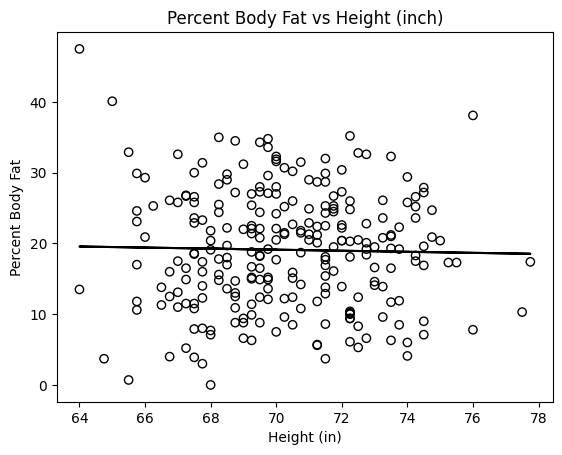

In [ ]:
# @title Exercise 2C: Generate a Scatterplot

import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

# Define variables
dataset = dsCopy                     # DataFrame name
colName1 = "height_in"               # Column with x values
colName2 = "percent_body_fat"        # Column with y value
plotTitle = "Percent Body Fat vs Height (inch)"
xLabel = "Height (in)"
yLabel = "Percent Body Fat"

# Assign x and y
x = dataset[colName1]
y = dataset[colName2]

# Create the scatter plot with open circles
plt.scatter(x, y, facecolors='none', edgecolors='black')

# Calculate the line of best fit
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

# Add the line to the plot
plt.plot(x, p(x), color='black')

# Generate the plot
plt.title(plotTitle)
plt.xlabel(xLabel)
plt.ylabel(yLabel)
plt.show()


If the code is correct, you should see the following output:

![__](https://biologicslab.co/STA1403/images/chapter_03/chapter_03A_image04B.png)

The plot above shows the scatterplot after removing the outlier. (Removing cases from a data set was discussed in the previous chapter.) Now, the two variables seem to be unrelated since the straight line, which properly captures the overall pattern, is almost horizontal. (Its slope is almost zero.) In this case, there is no substantial systematic changes (increase or decrease) in percent body fat as height increases.

### **_Correlation_**

We can also create pairwise scatterplots of multiple numerical variables. This is useful when we are investigating possible relationships
among several variables. To illustrate this, we use the `Protein` data set discussed in the previous chapter. Unlike the above two examples, where there was a single target variable (percent body fat or mortality rate), in this example, we are interested in possible relationships between multiple sources of food.


In [ ]:
#!pip -q install seaborn

### Generate Pair Plot

The code in the cell below generates a Pair Plot of 4 columns in the Protein dataset: `Cereals`, `Eggs`, `RedMeat` and `Fish`.

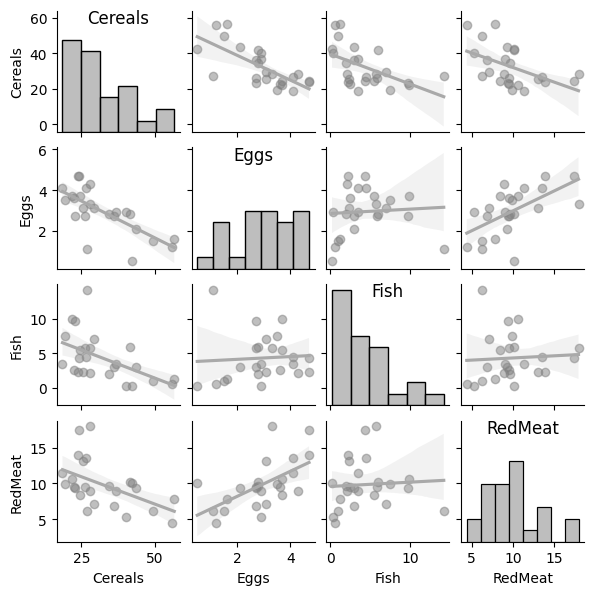

In [ ]:
# @title Generate Pair Plot

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Read Protein data file using Pandas read_csv() function
prot_df = pd.read_csv("https://biologicslab.co/STA1403/data/Protein.txt",
                  sep=' ', # define space as delimiter
                  na_values=["?", "NA", "null", ""])

# Define variables
dataset = prot_df       # DataFrame name
colNames = ["Cereals",
            "Eggs",
            "Fish",
            "RedMeat"]  # Columns with x values

# Generate Pair Plot
g = sns.pairplot(dataset[colNames],
                 height=1.5,
                 kind="reg",
                 diag_kind="hist",
                 corner=False,
                 plot_kws={'scatter_kws': {'color': 'grey',
                                           'alpha': 0.5},
                           'line_kws': {'color': 'darkgrey'}},
                 diag_kws={'color': 'darkgrey',
                           'edgecolor': 'black'})

# Add labels to the diagonal axes like in the image
axes = g.axes
for i, name in enumerate(prot_df[colNames]):
    axes[i, i].annotate(name, xy=(0.5, 0.9),
                        xycoords='axes fraction',
                        ha='center',
                        fontsize=12)

# Generate the plot
plt.show()

If the code is correct, you should see the following output:

![__](https://biologicslab.co/STA1403/images/chapter_03/chapter_03A_image15A.png)


The output, shown above is a **matrix of plots**. The diagonal plots are histograms of the respective variable. The off-diagonals are the scatterplots of the ith row variable and jth column variable. The 1st row and column correspond to `Cereals`; the 2nd row and column correspond to `Eggs`; the 3rd row and column correspond to `RedMeat`, and the 4th row and column correspond to `Fish`. Consumption of eggs seems to be negatively related to consumption of cereals. That is, in European countries, high consumption of eggs tends to coincide with low consumption of cereals. On the other hand, consumption of eggs has a positive linear relationship with consumption of red meat. While consumption of fish seems to have a negative linear relationship with consumption of cereals, it does not seem to be linearly related to consumptions of eggs and red meat.

_Correlation_ &nbsp;&nbsp;&nbsp;&nbsp;As shown in this Pair Plot, consumption of cereals has negative linear relationships with consumption of eggs, red meat, and fish. Which linear relationship seems to be stronger? To quantify the strength and direction of a linear relationship between two numerical variables, we can use **Pearson's correlation coefficient**, $r$, as a summary statistic. The values of $r$ are always between $-1$ and $+1$. When $r$ is close to zero, the linear relationship between the two variables is weak. As $r$ moves away from zero either toward $-1$ or $1$, it indicates that the linear relationship is relatively strong. The sign of $r$ shows the direction (negative or positive) of the linear relationship. A positive correlation coefficient means that when one variable increases, the other variable tends to increase too. A negative correlation coefficient, on the other hand, indicates that when one variable increases, the other variable tends to decrease.


------------------

>Consider a set of observed pairs of values, $(x_{n}, y_{n})$, $(x_{n}, y_{n})$, $\ldots$, $(x_{n}, y_{n})$, for a sample of $n$ observations. For these data, Pearson's correlation coefficient is calculated as follows:
$$
r _ {x y} = \frac {\sum_ {i = 1} ^ {n} \left(x _ {i} - \bar {x}\right) \left(y _ {i} - \bar {y}\right)}{(n - 1) s _ {x} s _ {y}}.
$$
>Here, $x_{i}$ is the observed value of the variable X for the ith observation, and $y_{i}$ is the observed value of the variable Y for the same observation. For the two variables, $\bar{x}$ and $\bar{y}$ denote the sample means, and $s_{x}$ and $s_{y}$ denote the sample standard deviations. If the standard deviations are removed from the denominator, the statistic is called the **sample covariance**,
$$
v _ {x y} = \frac {\sum_ {i = 1} ^ {n} \left(x _ {i} - \bar {x}\right) \left(y _ {i} - \bar {y}\right)}{n - 1}.
$$
Therefore,
$$
r _ {x y} = \frac {v _ {x y}}{s _ {x} s _ {y}}.
$$
---------------

For example, suppose that we have measured the height in inches and weight in pounds for five people. We denote height as X and weight as Y. In the following pairs of observations, the first element is the height of an individual, and the second element is his or her weight:

(62, 160), (71, 198), (65, 173), (73, 182), (60, 143).

We typically present such data in a tabular format shown below.

![__](https://biologicslab.co/STA1403/images/chapter_03/chapter_03A_image11A.png)

>**Table 3.1** Height (in inches) and weight (in pounds) for five individuals

Now we can calculate $r$ as in Table 3.2. Therefore, the sample correlation coefficient between height and weight is

$$
r _ {x y} = \frac {\sum_ {i = 1} ^ {n} \left(x _ {i} - \bar {x}\right) \left(y _ {i} - \bar {y}\right)}{(n - 1) s _ {x} s _ {y}} = \frac {421.8}{4 \times 5 . 6 \times 21.0} = 0.89.
$$

Here, the numerator $421.8$ is obtained by adding up the last column of Table 3.2.

Based on our data, height and weight seem to have a strong positive correlation.

![__](https://biologicslab.co/STA1403/images/chapter_03/chapter_03A_image12A.png)

**Table 3.2** Calculating Pearson’s correlation coefficient for height and weight

All the studies discussed in this section are observational studies. Therefore, if there is a relationship between two variables, it should not be considered as causation. All we can say in such cases is that the two variables are associated with each other.

In Python, computing a correlation matrix is straightforward as shown below in Example 3.

## Example 3: Compute Pearson's Correlation Matrix

The code in the cell below, shows the Python code to computer the correlation matrix for body fat (`percent_body_fat`) and the waist measurement (`abdomen_cm`).  

In [ ]:
# @title Example 3: Compute Correlation Matrix

import pandas as pd

# Define variables
dataset = bodyfat_df       # DataFrame name
colNames = ["abdomen_cm", "percent_body_fat",]

# Compute correlation matrix
corr_matrix = round(dataset[colNames].corr(method="pearson"), 4)

# Print results
print(corr_matrix)

                  abdomen_cm  percent_body_fat
abdomen_cm            1.0000            0.8134
percent_body_fat      0.8134            1.0000


If the code is correct, you should see the following output:
```text
                  abdomen_cm  percent_body_fat
abdomen_cm            1.0000            0.8126
percent_body_fat      0.8126            1.00000
```

The output is in the form of a symmetric matrix called the **correlation matrix**, where the value in row $i$ and column $j$ is the correlation coefficient between the $i$th and $j$th variables. As shown above, the correlation coefficient for `abdomen_cm` and `percent_body_fat` is $r = 0.81$, indicating a strong positive linear relationship. The diagonal elements in the correlation matrix are always 1, since a variable is perfectly and positively correlated with itself. Likewise, correlation matrices are symmetric since the order of the variables does not matter: $r_{xy} = r_{yx}$ .

## **Exercise 3: Compute Correlation Matrix**

In the cell below, write the code to compute the correlation matrix for the columns `Cereals`, `Eggs`, `Fish` and `RedMeat` in the `prot_df` DataFrame.

**Code Hints:**

1. Copy-and-paste Example 3 into the cell below.
2. Change the variables to read as shown in the following code block:
```Python
# Define variables
dataset = prot_df       # DataFrame name
colNames = ["Cereals", "Eggs", "Fish", "RedMeat"]

```

In [ ]:
# @title Exercise 3: Compute Correlation Coefficient

import pandas as pd

# Define variables
dataset = prot_df       # DataFrame name
colNames = ["Cereals", "Eggs", "Fish", "RedMeat"]

# Compute correlation matrix
corr_matrix = round(dataset[colNames].corr(method="pearson"), 4)

# Print results
print(corr_matrix)

         Cereals    Eggs    Fish  RedMeat
Cereals   1.0000 -0.7124 -0.5242  -0.4999
Eggs     -0.7124  1.0000  0.0656   0.5856
Fish     -0.5242  0.0656  1.0000   0.0610
RedMeat  -0.4999  0.5856  0.0610   1.0000


If the code is correct, you should see the following output:
```text
         Cereals    Eggs    Fish  RedMeat
Cereals   1.0000 -0.7124 -0.5242  -0.4999
Eggs     -0.7124  1.0000  0.0656   0.5856
Fish     -0.5242  0.0656  1.0000   0.0610
RedMeat  -0.4999  0.5856  0.0610   1.0000

```

We can obtain the correlation matrix for multiple variables following the same steps as described above. The output above shows the correlation matrix for `Cereals`, `Eggs`, `Fish`, and `RedMeat`. There is a strong negative linear relationship $(r = -0.71)$ between `Cereals` and `Eggs`. The sample correlation coefficient between `Cereals` and `Fish` is also negative $(r = -0.52)$. However, the negative linear relationship between `Cereals` and `Fish` is not as strong as the negative linear relationship between `Cereals` and `Eggs`. The correlation coefficient between `Fish` and `RedMeat` is close to zero $(r = 0.06)$, which indicates that the linear relationship between these two variables is weak.

# **Electronic Submission**

When you run the code in the cell below, it will grade your Colab notebook and tell you your pending grade as it currently stands. You will be given the choice to either submit your notebook for final grading or the option to continue your work on one (or more) Exercises.

Grant Access to your Colab Secrets if you are asked to do so.

In [ ]:
# @title Electronic Submission

import urllib.request
import ssl
import time

url = "https://biologicslab.co/STA1403/backend_code/validate.py?v=" + str(time.time())

ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

req = urllib.request.Request(
    url,
    headers={
        "Cache-Control": "no-cache, no-store, must-revalidate",
        "Pragma": "no-cache",
        "Expires": "0"
    }
)

with urllib.request.urlopen(req, context=ctx) as r:
    exec(r.read().decode("utf-8"))

main()